# Model Comparison

The purpose of this notebook is to compare the baseline with more flexible classification models that can capture nonlinear relationships and interactions between features. All models will be evaluated using the same training data, preprocessing strategy, cross-validation procedure, and performance metrics to ensure a fair comparison.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV




## 1. Data Preparation

In [2]:
df = pd.read_csv(
    "../data/processed/telco_customer_churn_cleaned.csv"
)

In [3]:
selected_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

X = df[selected_features]

y = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

categorical_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

In [6]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 2. Model Comparison

The Logistic Regression model established in the previous notebook provides a simple and interpretable baseline. However, customer churn may depend on nonlinear relationships and interactions between multiple customer characteristics that a linear model cannot fully capture.

Therefore, two ensemble-based models will be evaluated: Random Forest and Gradient Boosting. These models are commonly used for structured tabular data and can capture more complex relationships without requiring them to be specified manually.

All models will be compared using the same training dataset, cross-validation strategy, and evaluation metrics. The held-out test set will remain untouched until the final model selection stage.

### 2.1 Random Forest

Random Forest is an ensemble of decision trees trained on different subsets of the data and features. By averaging the predictions of many trees, it is generally more stable and less prone to overfitting than a single Decision Tree.

In [7]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [8]:
rf_cv_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision"
    ],
    n_jobs=-1
)

In [9]:
rf_cv_summary = pd.DataFrame({
    "Mean": {
        "Accuracy": rf_cv_results["test_accuracy"].mean(),
        "Precision": rf_cv_results["test_precision"].mean(),
        "Recall": rf_cv_results["test_recall"].mean(),
        "F1": rf_cv_results["test_f1"].mean(),
        "ROC-AUC": rf_cv_results["test_roc_auc"].mean(),
        "PR-AUC": rf_cv_results["test_average_precision"].mean()
    },
    "Std": {
        "Accuracy": rf_cv_results["test_accuracy"].std(),
        "Precision": rf_cv_results["test_precision"].std(),
        "Recall": rf_cv_results["test_recall"].std(),
        "F1": rf_cv_results["test_f1"].std(),
        "ROC-AUC": rf_cv_results["test_roc_auc"].std(),
        "PR-AUC": rf_cv_results["test_average_precision"].std()
    }
})

rf_cv_summary

,Mean,Std
Accuracy,0.800854,0.011360
Precision,0.652979,0.028954
Recall,0.533779,0.018633
F1,0.587281,0.021567
ROC-AUC,0.845457,0.010904
PR-AUC,0.639777,0.031988


The initial Random Forest model does not outperform the Logistic Regression baseline. Its accuracy and ROC-AUC are slightly lower, while recall, F1-score, and PR-AUC show a more noticeable decrease. This suggests that the additional model complexity does not provide an immediate advantage with the default hyperparameter configuration. Hyperparameter tuning will be considered before drawing a final conclusion about the model.

### 2.2 Gradient Boosting

Gradient Boosting is another ensemble-based method, but unlike Random Forest it builds trees sequentially. The model will first be evaluated using its default configuration and the same cross-validation strategy used for the previous models.

In [10]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

In [11]:
gb_cv_results = cross_validate(
    gb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision"
    ],
    n_jobs=-1
)

In [12]:
gb_cv_summary = pd.DataFrame({
    "Mean": {
        "Accuracy": gb_cv_results["test_accuracy"].mean(),
        "Precision": gb_cv_results["test_precision"].mean(),
        "Recall": gb_cv_results["test_recall"].mean(),
        "F1": gb_cv_results["test_f1"].mean(),
        "ROC-AUC": gb_cv_results["test_roc_auc"].mean(),
        "PR-AUC": gb_cv_results["test_average_precision"].mean()
    },
    "Std": {
        "Accuracy": gb_cv_results["test_accuracy"].std(),
        "Precision": gb_cv_results["test_precision"].std(),
        "Recall": gb_cv_results["test_recall"].std(),
        "F1": gb_cv_results["test_f1"].std(),
        "ROC-AUC": gb_cv_results["test_roc_auc"].std(),
        "PR-AUC": gb_cv_results["test_average_precision"].std()
    }
})

gb_cv_summary

,Mean,Std
Accuracy,0.807599,0.008875
Precision,0.664261,0.021796
Recall,0.556522,0.016736
F1,0.605547,0.017432
ROC-AUC,0.862512,0.011696
PR-AUC,0.687249,0.019027


In [13]:
model_comparison = pd.DataFrame({
    "Logistic Regression": {
        "Accuracy": 0.81,
        "Precision": 0.67,
        "Recall": 0.58,
        "F1": 0.62,
        "ROC-AUC": 0.86,
        "PR-AUC": 0.68
    },
    "Random Forest": rf_cv_summary["Mean"],
    "Gradient Boosting": gb_cv_summary["Mean"]
})

model_comparison

,Logistic Regression,Random Forest,Gradient Boosting
Accuracy,0.81,0.800854,0.807599
Precision,0.67,0.652979,0.664261
Recall,0.58,0.533779,0.556522
F1,0.62,0.587281,0.605547
ROC-AUC,0.86,0.845457,0.862512
PR-AUC,0.68,0.639777,0.687249


The initial comparison shows that all three models achieve broadly similar performance. Logistic Regression remains highly competitive despite being the simplest model. Random Forest performs slightly worse across most metrics, while Gradient Boosting provides only a modest improvement in PR-AUC and comparable ROC-AUC. These results suggest that increased model complexity does not automatically translate into substantially better predictive performance. Further improvements will therefore focus on hyperparameter tuning, feature selection, and threshold optimization before selecting the final production model.

## 3. Feature Selection Experiments

The next step is to investigate whether all currently selected features are necessary. To avoid using information from the held-out test set for model selection, all feature selection decisions in this section are evaluated exclusively on the training data.

Logistic Regression coefficients fitted on the training set are used to identify candidate features for removal. These candidates are then evaluated using cross-validation to determine whether removing them changes predictive performance.

The held-out test set remains untouched.

In [14]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Gender','Senior Citizen','Partner',...,'Monthly Charges','Total Charges', 'CLTV']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthro

In [15]:
feature_names = (
    lr_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    lr_pipeline
    .named_steps["model"]
    .coef_[0]
)

lr_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

lr_coefficients["Absolute Coefficient"] = (
    lr_coefficients["Coefficient"].abs()
)

In [16]:
lr_coefficients_sorted = (
    lr_coefficients
    .sort_values("Absolute Coefficient", ascending=True)
    .reset_index(drop=True)
)

lr_coefficients_sorted.head(20)

,Feature,Coefficient,Absolute Coefficient
0,cat__Online Backup_No,0.006962,0.006962
1,cat__Paperless Billing_Yes,0.007045,0.007045
2,cat__Device Protection_Yes,-0.018451,0.018451
3,num__CLTV,0.024931,0.024931
4,cat__Partner_Yes,-0.026280,0.026280
5,cat__Device Protection_No,-0.039913,0.039913
6,cat__Online Backup_Yes,-0.065327,0.065327
7,cat__Multiple Lines_Yes,0.083965,0.083965
8,cat__Tech Support_No,0.115446,0.115446
9,cat__Payment Method_Mailed check,-0.118912,0.118912


### Logistic Regression - Reduced Feature Set

The first feature selection experiment evaluates a smaller set of predictors identified as potential candidates for removal based primarily on their weak contribution in the Logistic Regression model fitted on the training data and on practical considerations such as redundancy and production usefulness.

The goal is to test whether removing these variables changes cross-validation performance. If performance remains similar, the reduced feature set may be preferable (because it provides a simpler model with fewer input variables).

In [ ]:
candidate_features_for_removal = [
    "CLTV",
    "Gender",
    "Phone Service",
    "Multiple Lines"
]

reduced_features = [
    feature
    for feature in selected_features
    if feature not in candidate_features_for_removal
]

categorical_features_reduced = [
    feature
    for feature in categorical_features
    if feature not in candidate_features_for_removal
]

numeric_features_reduced = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

In [18]:
reduced_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_reduced),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_reduced
        )
    ]
)

lr_reduced_pipeline = Pipeline([
    ("preprocessor", reduced_preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [19]:
lr_reduced_cv_results = cross_validate(
    lr_reduced_pipeline,
    X_train[reduced_features],
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision"
    ],
    n_jobs=-1
)

In [20]:
lr_reduced_summary = pd.DataFrame({
    "Mean": {
        "Accuracy": lr_reduced_cv_results["test_accuracy"].mean(),
        "Precision": lr_reduced_cv_results["test_precision"].mean(),
        "Recall": lr_reduced_cv_results["test_recall"].mean(),
        "F1": lr_reduced_cv_results["test_f1"].mean(),
        "ROC-AUC": lr_reduced_cv_results["test_roc_auc"].mean(),
        "PR-AUC": lr_reduced_cv_results["test_average_precision"].mean()
    },
    "Std": {
        "Accuracy": lr_reduced_cv_results["test_accuracy"].std(),
        "Precision": lr_reduced_cv_results["test_precision"].std(),
        "Recall": lr_reduced_cv_results["test_recall"].std(),
        "F1": lr_reduced_cv_results["test_f1"].std(),
        "ROC-AUC": lr_reduced_cv_results["test_roc_auc"].std(),
        "PR-AUC": lr_reduced_cv_results["test_average_precision"].std()
    }
})

lr_reduced_summary

,Mean,Std
Accuracy,0.811859,0.013574
Precision,0.665731,0.029066
Recall,0.584615,0.038911
F1,0.622114,0.030886
ROC-AUC,0.858234,0.012875
PR-AUC,0.672338,0.022026


In [21]:
lr_cv_results = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision"
    ],
    n_jobs=-1
)

In [22]:
lr_cv_summary = pd.DataFrame({
    "Mean": {
        "Accuracy": lr_cv_results["test_accuracy"].mean(),
        "Precision": lr_cv_results["test_precision"].mean(),
        "Recall": lr_cv_results["test_recall"].mean(),
        "F1": lr_cv_results["test_f1"].mean(),
        "ROC-AUC": lr_cv_results["test_roc_auc"].mean(),
        "PR-AUC": lr_cv_results["test_average_precision"].mean()
    },
    "Std": {
        "Accuracy": lr_cv_results["test_accuracy"].std(),
        "Precision": lr_cv_results["test_precision"].std(),
        "Recall": lr_cv_results["test_recall"].std(),
        "F1": lr_cv_results["test_f1"].std(),
        "ROC-AUC": lr_cv_results["test_roc_auc"].std(),
        "PR-AUC": lr_cv_results["test_average_precision"].std()
    }
})


In [23]:
lr_feature_comparison = pd.DataFrame({
    "All Features": lr_cv_summary["Mean"],
    "Reduced Features": lr_reduced_summary["Mean"]
})

lr_feature_comparison

,All Features,Reduced Features
Accuracy,0.812036,0.811859
Precision,0.666785,0.665731
Recall,0.582609,0.584615
F1,0.621309,0.622114
ROC-AUC,0.858816,0.858234
PR-AUC,0.679871,0.672338


Removing CLTV, Gender, Phone Service, and Multiple Lines resulted in only negligible changes in cross-validation performance. This indicates that, within the training data and the evaluated Logistic Regression model, these variables provide little additional predictive value beyond the remaining predictors.

### Logistic Regression - Engineered Feature Set

The previous experiment showed that removing several weak features had only a negligible impact on Logistic Regression performance. The next experiment therefore focuses on feature engineering rather than further feature removal.

Several new variables will be created from existing customer attributes to capture potentially useful interactions and customer behavior patterns that are not represented explicitly in the original dataset.

The engineered feature set will contain original predictors without the weak features together with the newly created features. Its performance will be evaluated using the same Logistic Regression model and the same cross-validation procedure to ensure a fair comparison.

In [ ]:
X_train_engineered = X_train[reduced_features].copy()
service_columns = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

X_train_engineered["Service Count"] = (
    X_train_engineered[service_columns]
    .eq("Yes")
    .sum(axis=1)
)

X_train_engineered["Auto Payment"] = (
    X_train_engineered["Payment Method"]
    .isin([
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ])
    .astype(int)
)

X_train_engineered["Fiber Without Support"] = (
    (X_train_engineered["Internet Service"] == "Fiber optic")
    & (X_train_engineered["Tech Support"] == "No")
).astype(int)

X_train_engineered["Fiber Without Security"] = (
    (X_train_engineered["Internet Service"] == "Fiber optic")
    & (X_train_engineered["Online Security"] == "No")
).astype(int)

X_train_engineered["Early Tenure"] = (
    X_train_engineered["Tenure Months"] <= 6
).astype(int)

In [ ]:
y_train_engineered = y_train

engineered_numeric_features = numeric_features + [
    "Service Count"
]

engineered_numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Service Count",
    "Auto Payment",
    "Fiber Without Support",
    "Fiber Without Security",
    "Early Tenure"
]

engineered_categorical_features = categorical_features_reduced

In [26]:
engineered_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            engineered_numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            engineered_categorical_features
        )
    ]
)

In [27]:
lr_engineered_pipeline = Pipeline([
    ("preprocessor", engineered_preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [28]:
lr_engineered_cv_results = cross_validate(
    lr_engineered_pipeline,
    X_train_engineered,
    y_train_engineered,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision"
    ],
    n_jobs=-1
)

In [29]:
lr_engineered_summary = pd.DataFrame({
    "Mean": {
        "Accuracy": lr_engineered_cv_results["test_accuracy"].mean(),
        "Precision": lr_engineered_cv_results["test_precision"].mean(),
        "Recall": lr_engineered_cv_results["test_recall"].mean(),
        "F1": lr_engineered_cv_results["test_f1"].mean(),
        "ROC-AUC": lr_engineered_cv_results["test_roc_auc"].mean(),
        "PR-AUC": lr_engineered_cv_results["test_average_precision"].mean()
    },
    "Std": {
        "Accuracy": lr_engineered_cv_results["test_accuracy"].std(),
        "Precision": lr_engineered_cv_results["test_precision"].std(),
        "Recall": lr_engineered_cv_results["test_recall"].std(),
        "F1": lr_engineered_cv_results["test_f1"].std(),
        "ROC-AUC": lr_engineered_cv_results["test_roc_auc"].std(),
        "PR-AUC": lr_engineered_cv_results["test_average_precision"].std()
    }
})

lr_engineered_summary

,Mean,Std
Accuracy,0.812924,0.017588
Precision,0.672338,0.039543
Recall,0.575920,0.043832
F1,0.619938,0.038443
ROC-AUC,0.859714,0.012312
PR-AUC,0.674912,0.016161


In [30]:
feature_set_comparison = pd.DataFrame({
    "Original": lr_cv_summary["Mean"],
    "Reduced": lr_reduced_summary["Mean"],
    "Reduced + Engineered": lr_engineered_summary["Mean"]
})

feature_set_comparison

,Original,Reduced,Reduced + Engineered
Accuracy,0.812036,0.811859,0.812924
Precision,0.666785,0.665731,0.672338
Recall,0.582609,0.584615,0.575920
F1,0.621309,0.622114,0.619938
ROC-AUC,0.858816,0.858234,0.859714
PR-AUC,0.679871,0.672338,0.674912


The engineered features did not provide a meaningful improvement over the original feature set. This suggests that most of the information captured by the engineered variables was already represented in the original predictors, or that the available dataset contains limited additional predictive signal that can be extracted through simple feature engineering.

Since neither the original nor the engineered feature set provided a meaningful performance advantage, the reduced feature set will be used for the subsequent model optimization steps. It achieves comparable cross-validation performance while requiring fewer input variables, making it a simpler and more practical candidate for production deployment.

## 4. Hyperparameter Tuning

The reduced feature set will be used for hyperparameter optimization. The first model to be tuned will be Logistic Regression, with the goal of determining whether adjustments to model regularization can improve cross-validation performance.

In [ ]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

grid_search = GridSearchCV(
    estimator=lr_reduced_pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(
    X_train[reduced_features],
    y_train
)

In [32]:
grid_search.best_params_

{'model__C': 1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}

In [33]:
grid_search.best_score_

np.float64(0.672599313374214)

GridSearchCV selected L1-regularized Logistic Regression with C = 1 as the best configuration based on average precision. However, the improvement over the untuned reduced-feature model was negligible, with average precision increasing only from approximately 0.6723 to 0.6726. This suggests that the baseline Logistic Regression model was already close to its optimal configuration within the tested hyperparameter space.

### Gradient Boosting Hyperparameter Tuning

Because Gradient Boosting has several hyperparameters that control model complexity and learning dynamics, a limited hyperparameter search will be performed to determine whether its performance can be improved. The tuning will be performed only on the training data using cross-validation, while the test set will remain untouched.

In [ ]:
gb_tuning_pipeline = Pipeline([
    ("preprocessor", reduced_preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

gb_param_grid = {
    "model__n_estimators": [50, 100, 150, 200, 250],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [1, 2, 3],
    "model__min_samples_leaf": [1, 5, 10]
}

gb_grid_search = GridSearchCV(
    estimator=gb_tuning_pipeline,
    param_grid=gb_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

gb_grid_search.fit(
    X_train[reduced_features],
    y_train
)

In [35]:
gb_grid_search.best_params_

{'model__learning_rate': 0.03,
 'model__max_depth': 3,
 'model__min_samples_leaf': 10,
 'model__n_estimators': 250}

In [36]:
gb_grid_search.best_score_

np.float64(0.6881165880660417)

The tuned Gradient Boosting model achieved only a marginal improvement in average precision compared with the default configuration. Further extensive hyperparameter tuning is unlikely to provide substantial gains.

## 5. Final Model Selection

Logistic Regression was selected as the final production candidate. Its predictive performance was comparable to the more complex ensemble models, while offering lower model complexity, faster inference, easier interpretation, and simpler deployment.

The reduced feature set will be used because it achieved nearly identical cross-validation performance while requiring fewer input variables. The final model will be trained on the full training dataset and evaluated once on the held-out test set.

In [ ]:
final_pipeline = Pipeline([
    ("preprocessor", reduced_preprocessor),
    ("model", LogisticRegression(
        C=1,
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ))
])

final_pipeline.fit(
    X_train[reduced_features],
    y_train
)

y_test_proba = final_pipeline.predict_proba(
    X_test[reduced_features]
)[:, 1]

chosen_threshold = 0.35

y_test_pred = (
    y_test_proba >= chosen_threshold
).astype(int)

In [38]:
final_test_results = pd.Series({
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba),
    "PR-AUC": average_precision_score(y_test, y_test_proba)
})

final_test_results

Accuracy     0.775727
Precision    0.560417
Recall       0.719251
F1           0.629977
ROC-AUC      0.848046
PR-AUC       0.651052
dtype: float64

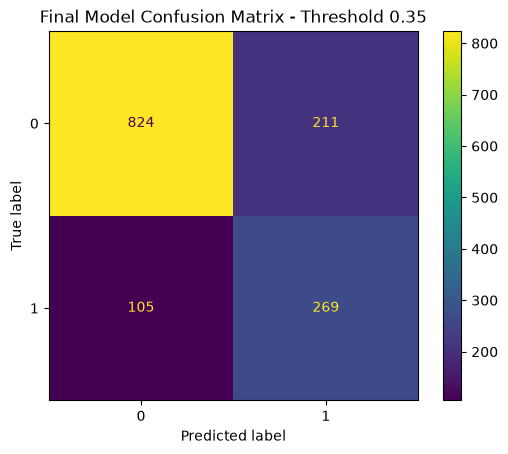

In [39]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred
)

plt.title("Final Model Confusion Matrix - Threshold 0.35")
plt.show()

The final Logistic Regression model achieved a recall of approximately 72% on the held-out test set, meaning that most actual churn customers were successfully identified. Precision was lower at approximately 56%, reflecting the expected increase in false positives caused by the reduced classification threshold of 0.35. The model achieved an ROC-AUC of approximately 0.85 and a PR-AUC of approximately 0.65, which are consistent with the cross-validation results and indicate reasonable generalization to unseen data.

Overall, the final model favors recall over precision. This operating point is appropriate for a recall-oriented churn detection scenario in which missing a potential churner is considered more costly than contacting some customers who would not actually churn.

## 6. Model Calibration

It is useful to evaluate whether the predicted probabilities are well calibrated. Calibration is evaluated using a calibration curve and the Brier score.

In [40]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

In [41]:
brier_score = brier_score_loss(
    y_test,
    y_test_proba
)

brier_score

0.13601316356810622

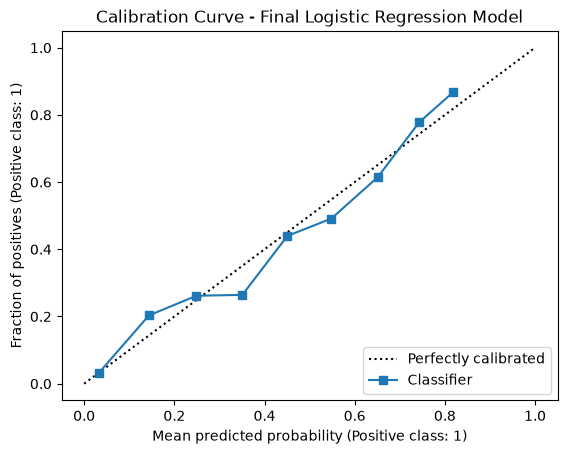

In [42]:
CalibrationDisplay.from_predictions(
    y_test,
    y_test_proba,
    n_bins=10
)

plt.title("Calibration Curve - Final Logistic Regression Model")
plt.show()

The calibration curve is reasonably close to the diagonal reference line, indicating that the predicted churn probabilities are fairly well calibrated overall.

Some deviations are visible in several probability ranges, but there is no strong systematic pattern of severe overconfidence or underconfidence. The Logistic Regression probabilities can be interpreted as approximate churn probabilities rather than only as ranking scores.